# Organelle expression by cell type, replicate and treatment

Chloroplast and mitochondrial expression summarised for every
`celltype_call` x `replicate` x `treatment` group.

**Where the counts come from.** Not `adata_rna.h5ad` - that object has no organelle genes at
all. It holds 36,042 features, all nuclear `Glyma.*`, because the collaborator dropped the
organelle contigs after computing `pctCP`. The organelle genes are in the CellRanger matrices
(52,996 features), so this notebook reads those and attaches the collaborator's cell
annotations (`celltype_call`, `replicate`, `treatment`) by barcode.

It uses the **collaborator's** CellRanger output rather than our realignment, since their
annotations are what is being grouped by. Nine of the thirteen libraries are bit-identical
between the two anyway; the four rep2 libraries are not, for reasons documented in
`Claude_analysis/README.md`.

In [2]:
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 40)

REPO = Path(r"C:\Users\mikep\git\Soybean_Single_Cell_drought_heat")
CELLRANGER = Path(r"C:\Users\mikep\Data\Cellranger_output")
ADATA_RNA = REPO / "Data" / "anndata_export" / "adata_rna.h5ad"
OUTDIR = REPO / "Initial_exploration" / "qc_results"

# `libraries` value in adata_rna.h5ad -> its CellRanger matrix directory
LIBRARY_TO_MATRIX = {
    "leaf_control_rep1": "control/rep1",
    "leaf_control_rep1A": "control/rep1a",
    "leaf_control_rep2": "control/rep2",
    "leaf_control_rep3": "control/rep3",
    "leaf_Heat_rep1": "heat/rep1",
    "leaf_Heat_rep2": "heat/rep2",
    "leaf_Heat_rep3": "heat/rep3",
    "leaf_drought_rep1": "drought/rep1",
    "leaf_drought_rep2": "drought/rep2",
    "leaf_drought_rep3": "drought/rep3",
    "leaf_HD_rep1": "HD/rep1",
    "leaf_HD_rep2": "HD/rep2",
    "leaf_HD_rep3": "HD/rep3",
}

GROUP_KEYS = ["celltype_call", "replicate", "treatment"]

## Which prefix is which organelle

The reference is `soy_Williams82_v3_with_organelles`, a custom build. Its non-nuclear features
carry three prefixes. The GTF is not available on this machine and the CellRanger `.h5` records
a single genome name with no per-contig field, so the mapping cannot be read directly off the
data. The identifiers `GlmaCp###` / `GlmaCt###` / `GlmaCr###` do not appear in Phytozome,
SoyBase, Ensembl Plants or any published annotation, so there is no external source to check
either.

### Leading interpretation: all three are chloroplast, split by biotype

`GlmaC` = *Glycine max* **c**hloroplast, with the fourth letter the biotype - **p**rotein-coding,
**t**RNA, **r**RNA. Two independent lines of evidence:

**Gene counts.** The soybean plastome (Saski et al. 2005, 152,218 bp) has 111 unique genes:
**77 protein-coding, 30 tRNA, 4 rRNA**, with 19 duplicated in the inverted repeat.

| prefix | genes here | plastome expectation |
|---|---|---|
| `GlmaCp` | 80 | 77 protein-coding + IR copies |
| `GlmaCt` | 36 | 30 tRNA + IR copies |
| `GlmaCr` | 8 | 4 rRNA x 2 IR copies |

**Expression shape** (control rep1, raw CellRanger counts):

| prefix | % reads | median counts/gene | genes at zero | reads like |
|---|---|---|---|---|
| `GlmaCp` | 1.45 | 486 | - | protein-coding: broadly expressed, top gene 13.5k |
| `GlmaCt` | 0.16 | 2 | 14 / 36 | tRNA: too short and not polyadenylated to be captured by 10x |
| `GlmaCr` | 21.5 | 0 | 6 / 8 | rRNA: one feature (`GlmaCr002`) carries 1.55M counts on its own |

The `GlmaCt` profile is the one that discriminates. Under the alternative reading - that
`GlmaCt` is the *mitochondrial* genome - plant mitochondrial protein-coding genes (nad, cox,
atp, ccm) would show up at percent-level in a plant cell, not 0.16% with a median of 2 counts
and a third of genes at exactly zero. That profile is a tRNA set. It also explains why there
are only three non-nuclear prefixes summing to 124 features, consistent with **one** organelle
genome rather than two.

If this is right, then **there is no mitochondrial genome in the reference at all**, which is
exactly why the collaborator's `pctMT` is zero for all 30,467 cells: their pattern had nothing
to match. And total chloroplast is `cp + ct + cr` - the `organelle_*` columns below - not the
`cp_*` columns alone.

### Still unconfirmed

This is inference, not a citation. One command on the HPC settles it, against the reference
used in `_cmdline`:

```bash
REF=/projects/rps/cgsb/bergelson/bergelson-lab/Michael_P/Collaborator_data/Genomes/soy_Williams82_v3_with_organelles
# which contig does each organelle feature sit on?
zcat $REF/genes/genes.gtf.gz | grep GlmaC | cut -f1 | sort | uniq -c
# contig names and lengths: chloroplast ~152 kb, soybean mitochondrion ~402 kb
grep "^>" $REF/fasta/genome.fa | grep -v "^>Gm"
```

If every `GlmaC*` feature sits on one ~152 kb contig, the biotype reading is confirmed. If they
split across two contigs of ~152 kb and ~402 kb, then `GlmaCt` is mitochondrial and the labels
below need swapping.

**All three prefixes are therefore reported separately below**, plus a combined `organelle`
column. Relabel via `ORGANELLE_SETS` once you know - nothing downstream depends on the labels.

In [3]:
# Reported separately because the prefix -> organelle mapping is inferred, not confirmed.
# Leading interpretation: GlmaC = Glycine max chloroplast, 4th letter = biotype, so all three
# are chloroplast and total chloroplast is the combined "organelle" set.
ORGANELLE_SETS = {
    "cp": ("GlmaCp",),  # 80 genes  -- chloroplast protein-coding
    "ct": (
        "GlmaCt",
    ),  # 36 genes  -- chloroplast tRNA (alternative reading: mitochondrial)
    "cr": ("GlmaCr",),  # 8 genes   -- chloroplast rRNA; ~20% of all reads
}

## Load the annotations, then the counts they refer to

In [4]:
obs = ad.read_h5ad(ADATA_RNA, backed="r").obs.copy()
print(f"{len(obs):,} annotated cells, {obs['celltype_call'].nunique()} cell types")
print(obs.groupby(["treatment", "replicate"], observed=True).size().to_string())

30,467 annotated cells, 9 cell types
treatment  replicate
Control    rep1         3740
           rep1A        3452
           rep2          823
           rep3         1683
Drought    rep1         1434
           rep2         2855
           rep3         1036
HD         rep1         5538
           rep2         3691
           rep3          702
Heat       rep1          939
           rep2         2381
           rep3         2193


In [5]:
parts, missing = [], {}
for library, rel in LIBRARY_TO_MATRIX.items():
    wanted = pd.Index(
        [
            name.rsplit("_", 1)[-1]
            for name in obs.index[obs["libraries"].astype(str) == library]
        ]
    )
    m = sc.read_10x_mtx(CELLRANGER / rel, var_names="gene_symbols")
    found = m.obs_names.intersection(wanted)
    if len(found) != len(wanted):
        missing[library] = len(wanted) - len(found)
    m = m[found].copy()
    m.obs_names = [f"{library}_{bc}" for bc in m.obs_names]
    parts.append(m)
    print(f"  {library:<22} {m.n_obs:>6,} cells")

counts = ad.concat(parts, join="outer")
del parts
counts.obs = obs.loc[counts.obs_names].copy()
print(
    f"\n{counts.n_obs:,} of {len(obs):,} annotated cells matched, "
    f"{counts.n_vars:,} features"
)
if missing:
    print("annotated barcodes absent from the CellRanger matrix:", missing)

  leaf_control_rep1       3,740 cells
  leaf_control_rep1A      3,452 cells
  leaf_control_rep2         823 cells
  leaf_control_rep3       1,683 cells
  leaf_Heat_rep1            939 cells
  leaf_Heat_rep2          2,381 cells
  leaf_Heat_rep3          2,193 cells
  leaf_drought_rep1       1,434 cells
  leaf_drought_rep2       2,855 cells
  leaf_drought_rep3       1,036 cells
  leaf_HD_rep1            5,538 cells
  leaf_HD_rep2            3,690 cells
  leaf_HD_rep3              702 cells

30,466 of 30,467 annotated cells matched, 52,996 features
annotated barcodes absent from the CellRanger matrix: {'leaf_HD_rep2': 1}


In [6]:
X = sparse.csr_matrix(counts.X)
symbols = pd.Index(counts.var_names.astype(str))

masks = {
    name: symbols.str.startswith(prefixes) for name, prefixes in ORGANELLE_SETS.items()
}
masks["organelle"] = np.logical_or.reduce(list(masks.values()))

total_umis = np.asarray(X.sum(axis=1)).ravel()
for name, mask in masks.items():
    print(
        f"{name:>10}: {int(mask.sum()):>3} genes, "
        f"{100 * X[:, mask].sum() / X.sum():6.2f}% of all reads"
    )

        cp:  80 genes,   1.19% of all reads
        ct:  36 genes,   0.13% of all reads
        cr:   8 genes,  19.58% of all reads
 organelle: 124 genes,  20.91% of all reads


### Cross-check against the collaborator's `pctCP`

Worth doing before trusting any of it: recompute each prefix's per-cell percentage and see how
it lines up with the `pctCP` they shipped. Note their percentage is computed on their
post-CellBender matrix while these are raw CellRanger counts, so the levels are not expected to
match exactly - the correlation is the informative part.

In [7]:
check = pd.DataFrame(
    {"pctCP_theirs": counts.obs["pctCP"].to_numpy()}, index=counts.obs_names
)
for name, mask in masks.items():
    sub = np.asarray(X[:, mask].sum(axis=1)).ravel()
    check[f"pct_{name}"] = 100 * sub / np.maximum(total_umis, 1)

print(check.describe().round(3).to_string())
print("\ncorrelation with their pctCP:")
print(check.corr()["pctCP_theirs"].drop("pctCP_theirs").round(3).to_string())
print(f"\ntheir pctMT is zero for every cell: {(counts.obs['pctMT'] == 0).all()}")

       pctCP_theirs     pct_cp     pct_ct     pct_cr  pct_organelle
count     30466.000  30466.000  30466.000  30466.000      30466.000
mean          7.201      1.114      0.124     16.674         17.911
std          11.539      0.827      0.138     14.664         15.175
min           0.000      0.000      0.000      0.000          0.000
25%           0.074      0.511      0.000      6.387          7.122
50%           1.066      0.937      0.097     13.693         14.875
75%          10.526      1.515      0.189     23.319         24.961
max          91.935     11.057      1.826     80.908         82.992

correlation with their pctCP:
pct_cp           0.422
pct_ct           0.301
pct_cr           0.749
pct_organelle    0.749

their pctMT is zero for every cell: True


## The table

One row per `celltype_call` x `replicate` x `treatment`. For each organelle set:

* **`*_total`** - total expression: every UMI in the group assigned to a gene in that set.
* **`*_median_gene`** - median expression across genes: each gene's summed counts within the
  group, then the median over the genes in the set. A robust "typical gene" figure that a few
  dominant genes cannot pull around.
* **`*_median_gene_per_cell`** - the same divided by `n_cells`, so groups of very different
  size stay comparable.
* **`*_pct_reads`** - percent of the group's reads coming from that set.

In [8]:
labels = counts.obs[GROUP_KEYS].astype(str).agg(" | ".join, axis=1)
groups = pd.Categorical(labels)
indicator = sparse.csr_matrix(
    (np.ones(counts.n_obs), (groups.codes, np.arange(counts.n_obs))),
    shape=(len(groups.categories), counts.n_obs),
)
gene_totals = indicator @ X  # groups x genes

n_cells = pd.Series(
    np.bincount(groups.codes, minlength=len(groups.categories)),
    index=list(groups.categories),
)
table = pd.DataFrame(
    {
        "n_cells": n_cells,
        "total_umis": np.asarray(gene_totals.sum(axis=1)).ravel().astype(np.int64),
    },
    index=list(groups.categories),
)

for name, mask in masks.items():
    block = np.asarray(gene_totals[:, mask].todense())
    table[f"{name}_total"] = block.sum(axis=1).astype(np.int64)
    table[f"{name}_median_gene"] = np.median(block, axis=1)
    table[f"{name}_median_gene_per_cell"] = np.median(block, axis=1) / table["n_cells"]
    table[f"{name}_pct_reads"] = 100 * table[f"{name}_total"] / table["total_umis"]

table.index = pd.MultiIndex.from_tuples(
    [tuple(s.split(" | ")) for s in table.index], names=GROUP_KEYS
)
table = table.sort_index().round(4)
print(f"{len(table)} groups")
table

112 groups


n_cells  total_umis  cp_total  cp_median_gene  cp_median_gene_per_cell  cp_pct_reads  ct_total  ct_median_gene  ct_median_gene_per_cell  ct_pct_reads  cr_total  cr_median_gene  \
celltype_call              replicate treatment                                                                                                                                                                                    
Bundle sheath              rep1      Control        630      756646      8349            39.5                   0.0627        1.1034       948             0.0                      0.0        0.1253    128682             0.0   
                                     Drought        283      323196      4538            13.0                   0.0459        1.4041       521             0.0                      0.0        0.1612     80472             3.5   
                                     HD             800      783340      5379            19.0                   0.0238        0.6867       899             0.0                      0.0        0.1148     72940             0.0   
                                     Heat           184      170671      1954             9.0                   0.0489        1.1449       145             0.0                      0.0        0.0850     25383             0.5   
                           rep1A     Control        676      749184     12218            46.5                   0.0688        1.6308      1028             0.0                      0.0        0.1372    114404             0.5   
...                                                 ...         ...       ...             ...                      ...           ...       ...             ...                      ...           ...       ...             ...   
Vascular/Phloem parenchyma rep2      Heat            57       63387       367             1.0                   0.0175        0.5790        38             0.0                      0.0        0.0599     10160             0.0   
                           rep3      Control         36       33778       205             1.0                   0.0278        0.6069        18             0.0                      0.0        0.0533        31             0.0   
                                     Drought         17       15978        75             0.0                   0.0000        0.4694        11             0.0                      0.0        0.0688        21             0.0   
                                     HD              11       13980        91             0.0                   0.0000        0.6509        11             0.0                      0.0        0.0787        20             0.0   
                                     Heat            40       38133       185             1.0                   0.0250        0.4851        13             0.0                      0.0        0.0341        83             0.0   

                                                cr_median_gene_per_cell  cr_pct_reads  organelle_total  organelle_median_gene  organelle_median_gene_per_cell  organelle_pct_reads  
celltype_call              replicate treatment                                                                                                                                      
Bundle sheath              rep1      Control                     0.0000       17.0069           137979                   11.5                          0.0183              18.2356  
                                     Drought                     0.0124       24.8988            85531                    5.0                          0.0177              26.4641  
                                     HD                          0.0000        9.3114            79218                    5.0                          0.0062              10.1129  
                                     Heat                        0.0027       14.8725            27482                    2.0                          0.0109              16.1023  
          

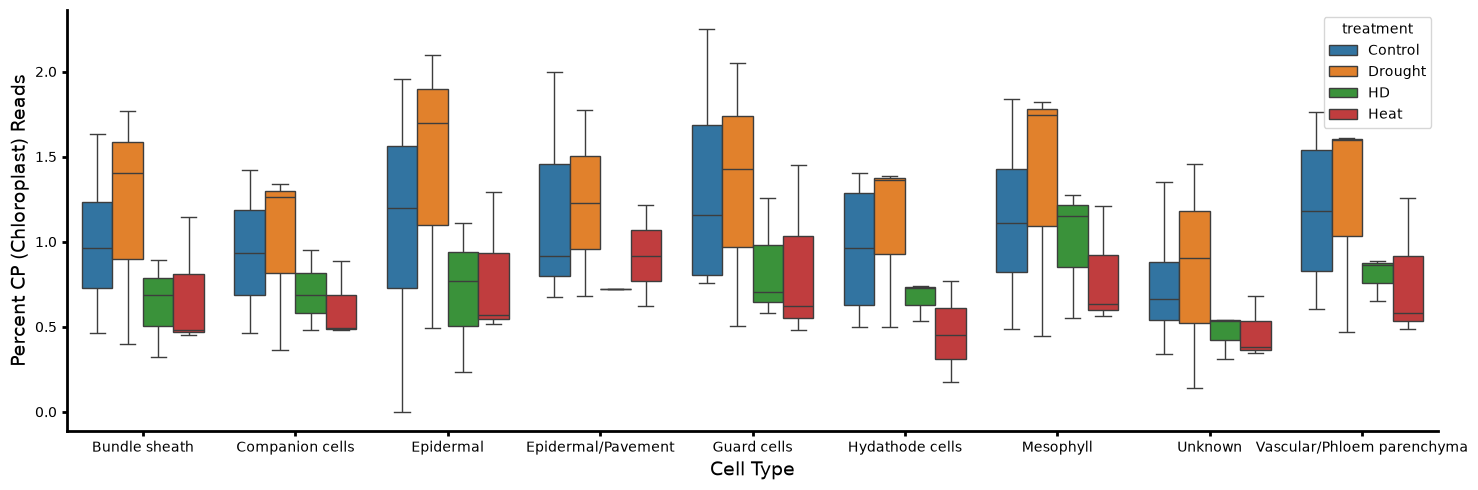

In [9]:
fig, ax = plt.subplots(figsize=(15, 5))
fig.patch.set_facecolor("white")
ax = sns.boxplot(
    data=table.reset_index(),
    x="celltype_call",
    y="cp_pct_reads",
    hue="treatment",
    showfliers=True,
)
plt.xlabel("Cell Type", fontsize=14)
plt.ylabel("Percent CP (Chloroplast) Reads", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

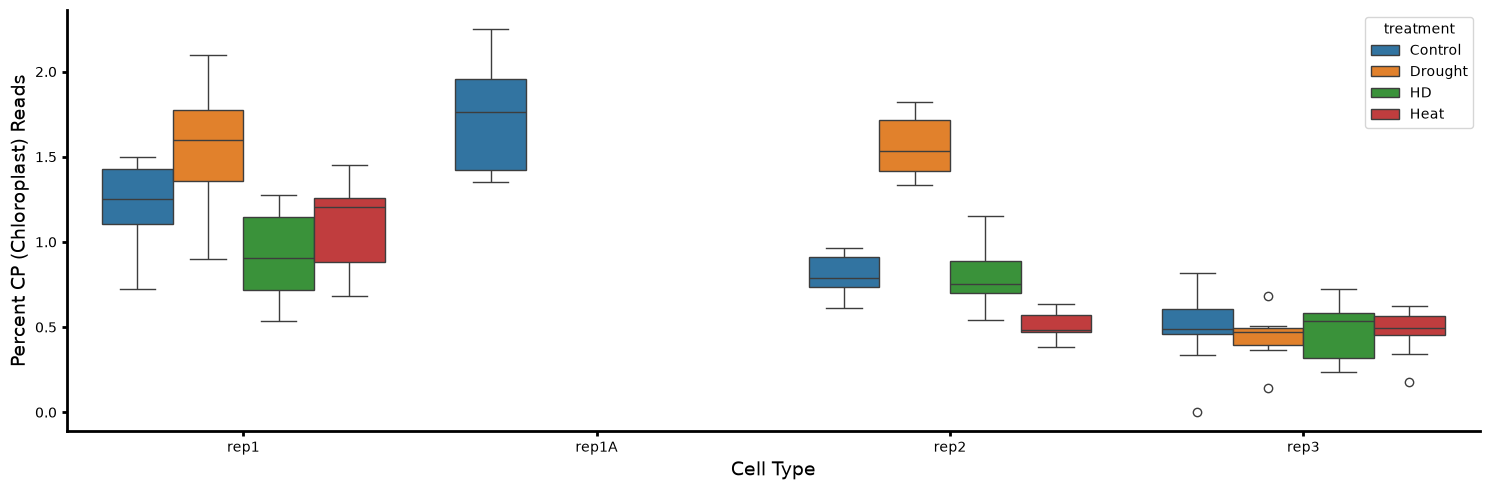

In [10]:
fig, ax = plt.subplots(figsize=(15, 5))
fig.patch.set_facecolor("white")
ax = sns.boxplot(
    data=table.reset_index(),
    x="replicate",
    y="cp_pct_reads",
    hue="treatment",
    showfliers=True,
)
plt.xlabel("Cell Type", fontsize=14)
plt.ylabel("Percent CP (Chloroplast) Reads", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

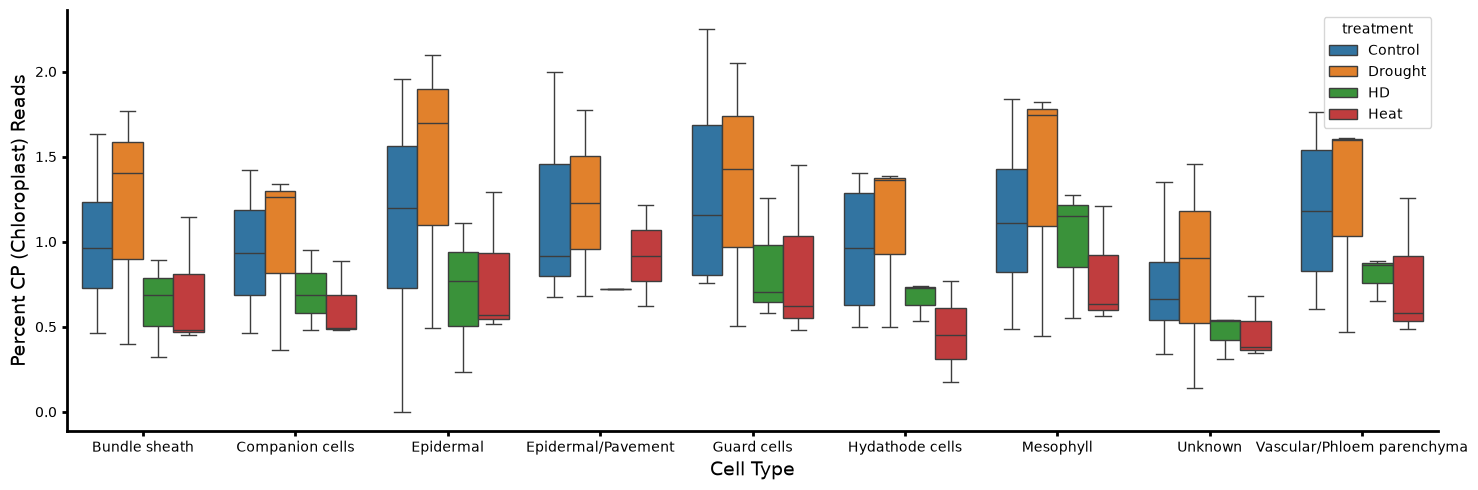

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))
fig.patch.set_facecolor("white")
ax = sns.boxplot(
    data=table.reset_index(),
    x="celltype_call",
    y="cp_pct_reads",
    hue="treatment",
    showfliers=True,
)
plt.xlabel("Cell Type", fontsize=14)
plt.ylabel("Percent CP (Chloroplast) Reads", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [12]:
OUTDIR.mkdir(exist_ok=True)
table.to_csv(OUTDIR / "organelle_expression_by_celltype_replicate_treatment.csv")

# tidy/long form, easier to filter and plot
tidy = (
    table.drop(columns=["n_cells", "total_umis"])
    .stack(future_stack=True)
    .rename("value")
    .reset_index()
    .rename(columns={"level_3": "metric"})
)
tidy["organelle_set"] = tidy["metric"].str.split("_").str[0]
tidy["metric"] = tidy["metric"].str.split("_", n=1).str[1]
tidy = tidy.merge(table[["n_cells", "total_umis"]].reset_index(), on=GROUP_KEYS)
tidy.to_csv(OUTDIR / "organelle_expression_tidy.csv", index=False)
print(f"wrote both tables to {OUTDIR.resolve()}")
tidy.head()

wrote both tables to C:\Users\mikep\git\Soybean_Single_Cell_drought_heat\Initial_exploration\qc_results


,celltype_call,replicate,treatment,metric,value,organelle_set,n_cells,total_umis
0,Bundle sheath,rep1,Control,total,8349.0000,cp,630,756646
1,Bundle sheath,rep1,Control,median_gene,39.5000,cp,630,756646
2,Bundle sheath,rep1,Control,median_gene_per_cell,0.0627,cp,630,756646
3,Bundle sheath,rep1,Control,pct_reads,1.1034,cp,630,756646
4,Bundle sheath,rep1,Control,total,948.0000,ct,630,756646


### Percent of reads by treatment and replicate, per cell type

In [12]:
for name in list(ORGANELLE_SETS) + ["organelle"]:
    print(f"\n=== {name}: percent of reads")
    print(
        table[f"{name}_pct_reads"]
        .unstack("treatment")
        .reindex(columns=["Control", "Heat", "Drought", "HD"])
        .round(2)
        .to_string()
    )


=== cp: percent of reads
treatment                             Control  Heat  Drought    HD
celltype_call              replicate                              
Bundle sheath              rep1          1.10  1.14     1.40  0.69
                           rep1A         1.63   NaN      NaN   NaN
                           rep2          0.82  0.48     1.77  0.89
                           rep3          0.46  0.45     0.40  0.32
Companion cells            rep1          1.11  0.88     1.26  0.95
                           rep1A         1.42   NaN      NaN   NaN
                           rep2          0.76  0.48     1.34  0.69
                           rep3          0.46  0.49     0.36  0.48
Epidermal                  rep1          1.43  1.29     2.10  1.11
                           rep1A         1.96   NaN      NaN   NaN
                           rep2          0.97  0.57     1.70  0.77
                           rep3          0.00  0.52     0.49  0.24
Epidermal/Pavement         rep1     

### Notes

* `pctMT` in `adata_rna.h5ad` is zero for every cell, so it cannot be used to filter or
  interpret mitochondrial load. The `ct_*` columns here are the first real measurement of it.
* Organelle load varies far more by **replicate** than by cell type, which is the confound
  already noted in `Claude_analysis/README.md`: it tracks sequencing batch, not biology. Any
  comparison of organelle content across treatments has to be read within a replicate.
* Counts are raw CellRanger UMIs, before CellBender. Ambient RNA in leaf protoplast preps is
  organelle-heavy, so these percentages are upper bounds on what is genuinely intracellular.

---

# Within-replicate variation

How variable are the top 2,000 variable genes *inside* a single replicate, and does that
variability differ by cell type or by treatment?

Every gene is measured twice, at two resolutions, so the two can be compared directly:

* **cell** - dispersion across individual cells within a (replicate, group).
* **metacell** - the same, across metacells: pseudobulks of ~20 transcriptionally similar
  cells, built by k-means on the PCA inside each `library` x `celltype_call` block so that a
  metacell is pure for library, replicate, treatment *and* cell type.

The metacell arm is not cosmetic. This data is shallow (median ~850 UMI per cell), so at cell
resolution the median and the MAD of a gene are **zero for 98% of gene x group combinations**
and every robust statistic collapses. Aggregating ~20 cells moves gene detection from ~12% to
~82% and makes median-based measures usable. Both are plotted so the difference is visible
rather than asserted.

### Gene selection

The 2,000 genes are chosen **once across the whole dataset**, not per replicate, so every
replicate is scored on the same genes.

They are the top 2,000 by *variance of log-normalised expression*, rather than by
`sc.pp.highly_variable_genes`. At this sparsity the usual dispersion-based selection picks
genes that are almost never observed, which makes any variability metric a measurement of
dropout rather than of biology:

| selection | median detection rate | genes seen in >10% of cells |
|---|---|---|
| `flavor="seurat"` | 0.34% | 79 / 2000 |
| `flavor="cell_ranger"` | 1.06% | 67 / 2000 |
| **top 2k by variance** | **12.6%** | **1490 / 2000** |

`HVG_METHOD` below switches between them if you want the standard definition instead.
(`flavor="seurat_v3"`, which would handle this properly, needs `scikit-misc`, which is not
installed in this environment.)

Organelle genes are excluded throughout: a single feature, `GlmaCr002`, carries ~20% of all
reads and varies ~200x by replicate, so leaving it in would drive library-size normalisation
and swamp every gene-level comparison.

In [ ]:
from sklearn.cluster import KMeans

N_HVG = 2000
HVG_METHOD = "variance"  # "variance" | "seurat" | "cell_ranger"
EXCLUDE_ORGANELLE = True

TARGET_METACELL_SIZE = 20  # cells per metacell
MIN_CELLS_FOR_METACELLS = (
    40  # a library x celltype block smaller than this is not split
)
MIN_METACELL_SIZE = 5  # drop metacells smaller than this
MIN_UNITS_PER_GROUP = 3  # a (replicate, group) needs this many cells/metacells

SPLITS = ["celltype_call", "treatment"]
REPLICATE_ORDER = ["rep1", "rep1A", "rep2", "rep3"]
TREATMENT_ORDER = ["Control", "Heat", "Drought", "HD"]

In [ ]:
var_adata = (
    counts[:, ~masks["organelle"]].copy() if EXCLUDE_ORGANELLE else counts.copy()
)
var_adata.obs["library"] = var_adata.obs["libraries"].astype(str)
var_adata.layers["counts"] = var_adata.X.copy()
sc.pp.normalize_total(var_adata, target_sum=1e4)
var_adata.layers["norm"] = sparse.csr_matrix(var_adata.X).copy()  # CP10K, linear
sc.pp.log1p(var_adata)  # .X is log1p(CP10K)

if HVG_METHOD == "variance":
    lx = sparse.csr_matrix(var_adata.X)
    mu = np.asarray(lx.mean(axis=0)).ravel()
    gene_var = np.asarray(lx.multiply(lx).mean(axis=0)).ravel() - mu**2
    HVG = var_adata.var_names[np.argsort(gene_var)[::-1][:N_HVG]]
else:
    sc.pp.highly_variable_genes(var_adata, n_top_genes=N_HVG, flavor=HVG_METHOD)
    HVG = var_adata.var_names[var_adata.var["highly_variable"]]

hvg_idx = var_adata.var_names.get_indexer(HVG)
detection = np.asarray((var_adata.layers["norm"][:, hvg_idx] > 0).mean(axis=0)).ravel()
print(f"{len(HVG)} genes by HVG_METHOD={HVG_METHOD!r}")
print(
    f"  median detection rate {np.median(detection):.3f} | "
    f"seen in >10% of cells: {(detection > 0.10).sum()} / {len(HVG)}"
)

var_adata.var["highly_variable"] = var_adata.var_names.isin(HVG)
sc.pp.pca(var_adata, n_comps=50, use_highly_variable=True)

2000 genes by HVG_METHOD='variance'
  median detection rate 0.126 | seen in >10% of cells: 1490 / 2000


### Metacells

k-means on the PCA within each `library` x `celltype_call` block, with *k* set so metacells
average `TARGET_METACELL_SIZE` cells. Clustering inside the block is what guarantees a metacell
never mixes libraries, treatments or cell types, so the same metacells serve both splits.

In [ ]:
metacell = pd.Series("", index=var_adata.obs_names, dtype=object)
pca = var_adata.obsm["X_pca"]

for (lib, ct), idx in var_adata.obs.groupby(
    ["library", "celltype_call"], observed=True
).groups.items():
    if len(idx) < MIN_CELLS_FOR_METACELLS:
        continue
    k = max(2, len(idx) // TARGET_METACELL_SIZE)
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(
        pca[var_adata.obs_names.get_indexer(idx)]
    )
    metacell[idx] = [f"{lib}|{ct}|{c}" for c in km.labels_]

var_adata.obs["metacell"] = metacell.replace("", np.nan)
assigned = var_adata.obs["metacell"].notna().to_numpy()

mc = pd.Categorical(var_adata.obs.loc[assigned, "metacell"].astype(str))
indicator = sparse.csr_matrix(
    (np.ones(assigned.sum()), (mc.codes, np.arange(assigned.sum()))),
    shape=(len(mc.categories), int(assigned.sum())),
)
mc_counts = indicator @ sparse.csr_matrix(var_adata[assigned].layers["counts"])
mc_norm = np.asarray(mc_counts.todense())
mc_norm = 1e4 * mc_norm / np.maximum(mc_norm.sum(axis=1, keepdims=True), 1)

mc_obs = pd.DataFrame(
    [c.split("|") for c in mc.categories],
    columns=["library", "celltype_call", "_k"],
    index=list(mc.categories),
)
mc_obs = mc_obs.join(
    var_adata.obs.drop_duplicates("library").set_index("library")[
        ["replicate", "treatment"]
    ],
    on="library",
)
mc_obs["size"] = np.bincount(mc.codes, minlength=len(mc.categories))

keep = mc_obs["size"] >= MIN_METACELL_SIZE
mc_obs, mc_norm = mc_obs[keep], mc_norm[keep.to_numpy()]
print(
    f"{len(mc_obs):,} metacells from {int(assigned.sum()):,} cells "
    f"({int((~assigned).sum()):,} cells in blocks too small to split)"
)
print(
    f"metacell size: median {mc_obs['size'].median():.0f}, "
    f"range {mc_obs['size'].min()}-{mc_obs['size'].max()}"
)

1,423 metacells from 29,625 cells (841 cells in blocks too small to split)
metacell size: median 20, range 5-53


### Per-gene dispersion at both resolutions

For every (resolution, split, replicate, group) and each of the 2,000 genes, computed across
the units (cells or metacells) in that group:

| column | meaning |
|---|---|
| `median` | median expression, CP10K - "median variation" in the level sense |
| `cv` | coefficient of variation, sd / mean |
| `mad_over_median` | MAD / median, the robust analogue of CV |
| `fano` | variance / mean; equals ~1 for pure Poisson sampling noise |
| `mad`, `mean`, `detection` | supporting values |

In [ ]:
def gene_dispersion(M):
    """M: units x genes, CP10K. Per-gene statistics across units."""
    mean, med = M.mean(axis=0), np.median(M, axis=0)
    sd = M.std(axis=0, ddof=1)
    mad = np.median(np.abs(M - med), axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        cv = np.where(mean > 0, sd / mean, np.nan)
        fano = np.where(mean > 0, sd**2 / mean, np.nan)
        mad_over_median = np.where(med > 0, mad / med, np.nan)
    return dict(
        gene=list(HVG),
        mean=mean,
        median=med,
        cv=cv,
        fano=fano,
        mad=mad,
        mad_over_median=mad_over_median,
        detection=(M > 0).mean(axis=0),
    )


frames = []
for split in SPLITS:
    for rep in REPLICATE_ORDER:
        cells = var_adata[var_adata.obs["replicate"].astype(str) == rep]
        for grp, idx in cells.obs.groupby(
            cells.obs[split].astype(str), observed=True
        ).groups.items():
            if len(idx) < MIN_UNITS_PER_GROUP:
                continue
            M = np.asarray(cells[idx].layers["norm"][:, hvg_idx].todense())
            frames.append(
                pd.DataFrame(
                    {
                        "resolution": "cell",
                        "split_by": split,
                        "replicate": rep,
                        "group": grp,
                        "n_units": len(idx),
                        **gene_dispersion(M),
                    }
                )
            )

        block = mc_obs[mc_obs["replicate"].astype(str) == rep]
        for grp, sel in block.groupby(
            block[split].astype(str), observed=True
        ).groups.items():
            if len(sel) < MIN_UNITS_PER_GROUP:
                continue
            M = mc_norm[np.ix_(mc_obs.index.get_indexer(sel), hvg_idx)]
            frames.append(
                pd.DataFrame(
                    {
                        "resolution": "metacell",
                        "split_by": split,
                        "replicate": rep,
                        "group": grp,
                        "n_units": len(sel),
                        **gene_dispersion(M),
                    }
                )
            )

variation = pd.concat(frames, ignore_index=True)
variation["replicate"] = pd.Categorical(
    variation["replicate"], categories=REPLICATE_ORDER
)
print(f"{len(variation):,} gene x group rows")
variation.head()

172,000 gene x group rows


,resolution,split_by,replicate,group,n_units,gene,mean,median,cv,fano,mad,mad_over_median,detection
0,cell,celltype_call,rep1,Bundle sheath,1897,Glyma.20G204500.Wm82.a4.v1,9.597872,0.000000,2.329697,52.092346,0.000000,NaN,0.318925
1,cell,celltype_call,rep1,Bundle sheath,1897,Glyma.13G012200.Wm82.a4.v1,19.157747,14.727540,1.048746,21.071011,14.727540,1.0,0.699526
2,cell,celltype_call,rep1,Bundle sheath,1897,Glyma.11G232500.Wm82.a4.v1,29.248009,16.155088,1.212411,42.992851,16.155088,1.0,0.632578
3,cell,celltype_call,rep1,Bundle sheath,1897,Glyma.17G202700.Wm82.a4.v1,36.867649,18.416206,1.207226,53.730747,18.416206,1.0,0.641012
4,cell,celltype_call,rep1,Bundle sheath,1897,Glyma.18G057900.Wm82.a4.v1,14.344603,0.000000,1.624085,37.836082,0.000000,NaN,0.467580


In [ ]:
print("=== fraction of gene x group values that are exactly zero")
print(
    variation.groupby("resolution")[["median", "mad"]]
    .apply(lambda d: d.eq(0).mean())
    .round(3)
    .to_string()
)
print("\n=== fraction undefined (NaN)")
print(
    variation.groupby("resolution")[["cv", "mad_over_median"]]
    .apply(lambda d: d.isna().mean())
    .round(3)
    .to_string()
)
print("\n=== medians by resolution and replicate")
print(
    variation.groupby(["resolution", "replicate"], observed=True)[
        ["median", "cv", "mad_over_median", "fano", "detection"]
    ]
    .median()
    .round(3)
    .to_string()
)

=== fraction of gene x group values that are exactly zero
            median    mad
resolution               
cell         0.980  0.980
metacell     0.074  0.074

=== fraction undefined (NaN)
               cv  mad_over_median
resolution                        
cell        0.020            0.980
metacell    0.008            0.074

=== medians by resolution and replicate
                      median     cv  mad_over_median    fano  detection
resolution replicate                                                   
cell       rep1        0.000  3.114            1.000  13.087      0.119
           rep1A       0.000  3.091            1.000  12.449      0.109
           rep2        0.000  2.908            1.000  11.953      0.141
           rep3        0.000  3.330            1.000  13.443      0.101
metacell   rep1        1.111  0.858            0.581   0.951      0.828
           rep1A       1.162  0.768            0.489   0.792      0.857
           rep2        1.214  0.774            0.51

## Plots

`showfliers=False`: each box summarises 2,000 genes, and drawing every outlier hides the
boxes. Flip it in `styled_boxplot` to see them.

In [ ]:
def styled_boxplot(
    data,
    x,
    y,
    hue,
    xlabel,
    ylabel,
    title=None,
    figsize=(15, 5),
    showfliers=False,
    hue_order=None,
    order=None,
):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax = sns.boxplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        showfliers=showfliers,
        hue_order=hue_order,
        order=order,
    )
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    if title:
        plt.title(title, fontsize=16)
    sns.despine()
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(2)
    ax.tick_params(axis="both", width=2)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=9)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()
    return ax


METRIC_LABELS = {
    "median": "Median expression (CP10K)",
    "cv": "Coefficient of variation",
}
SPLIT_LABELS = {"celltype_call": "cell type", "treatment": "treatment"}

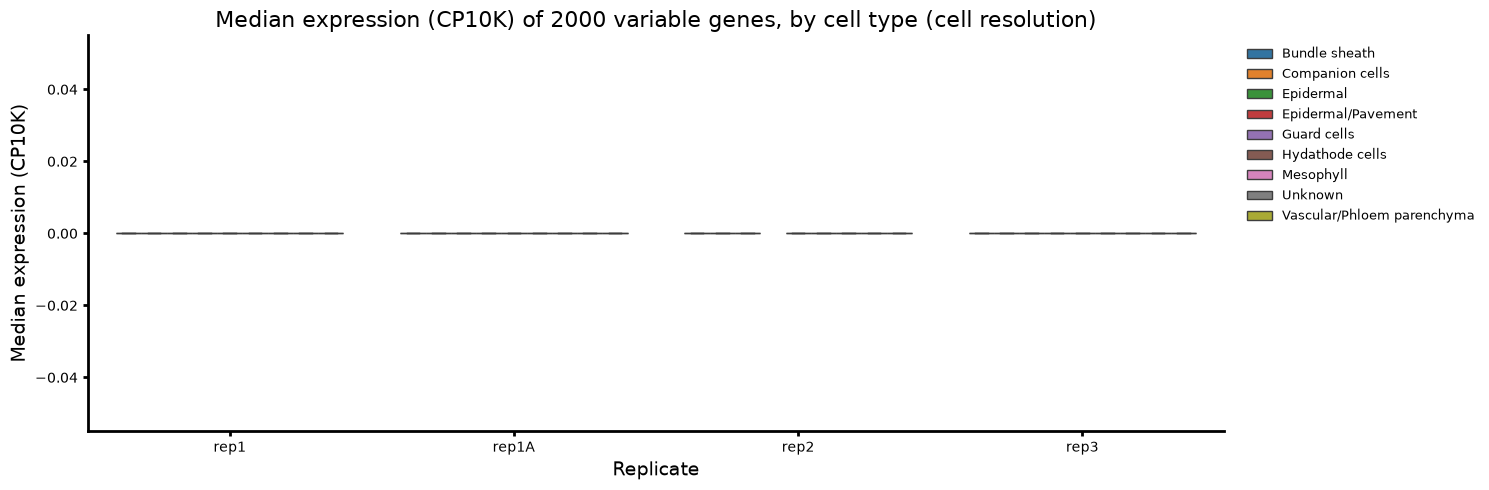

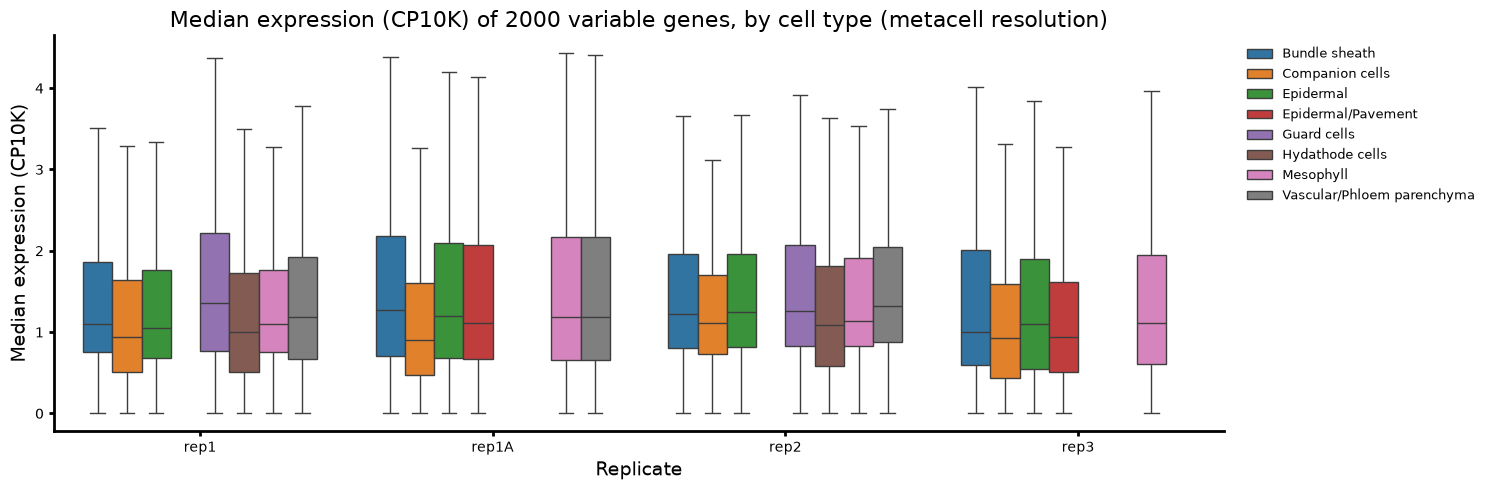

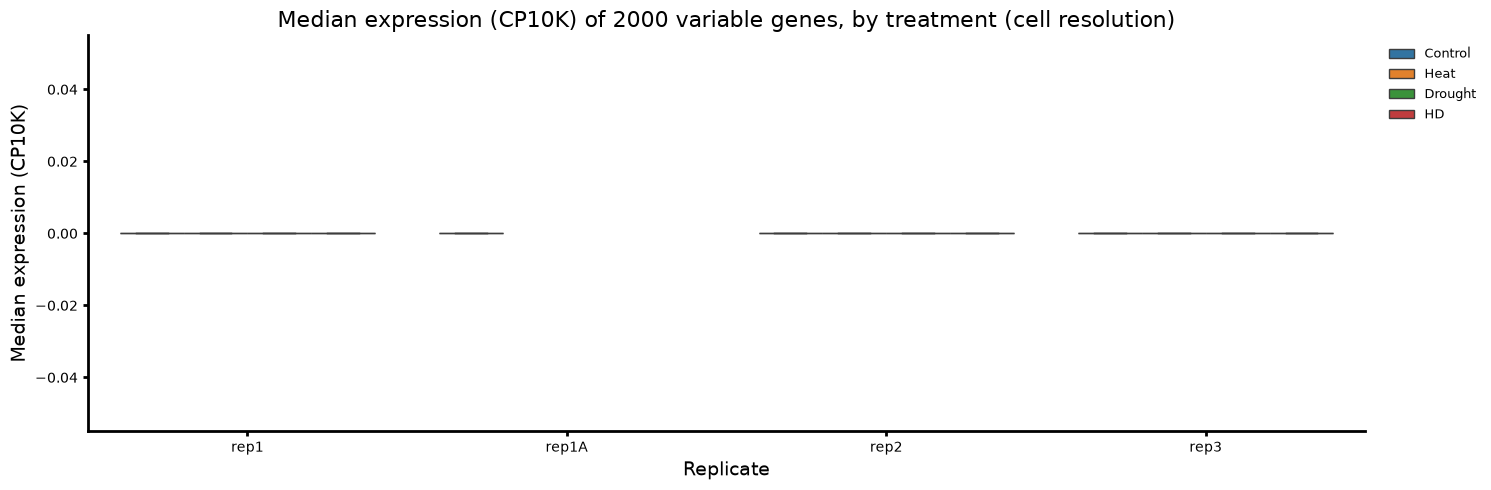

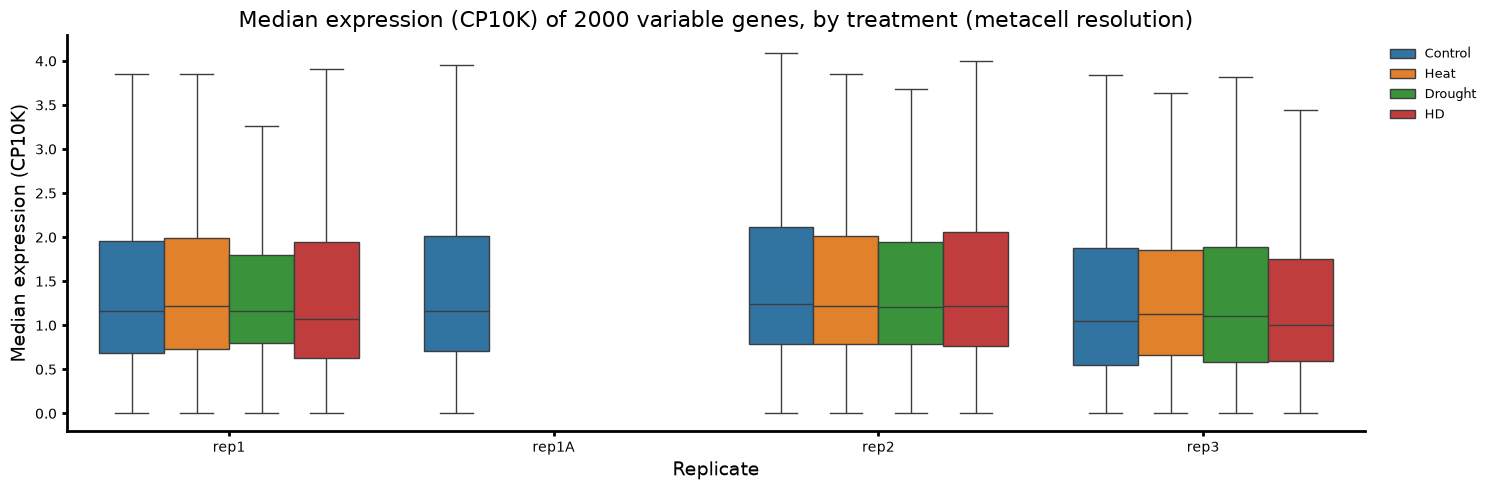

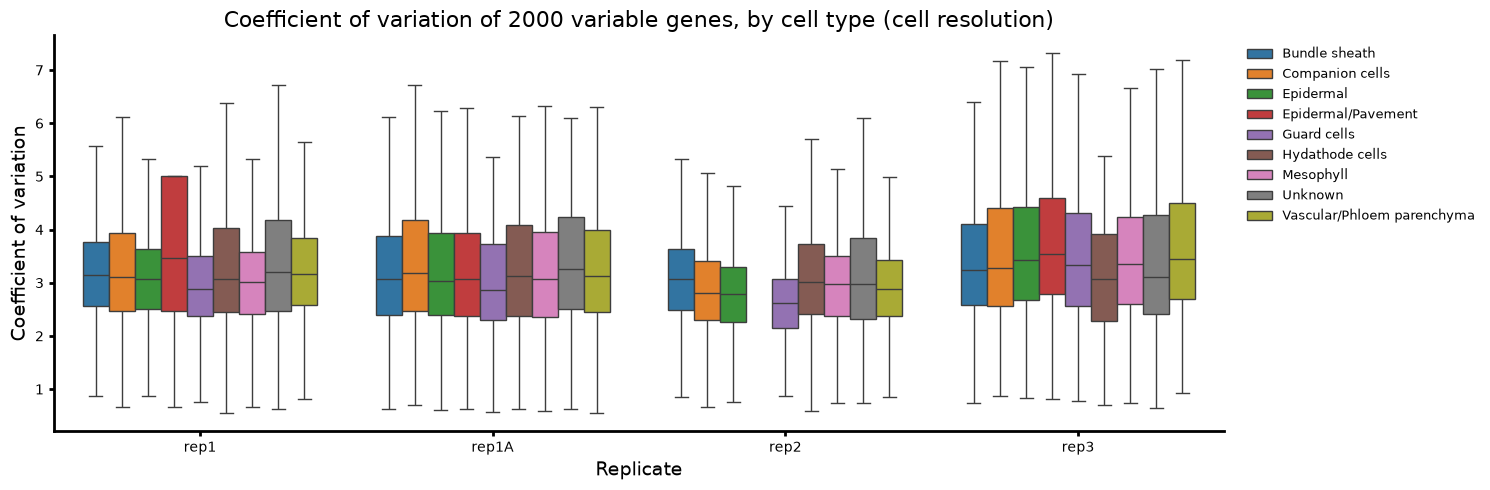

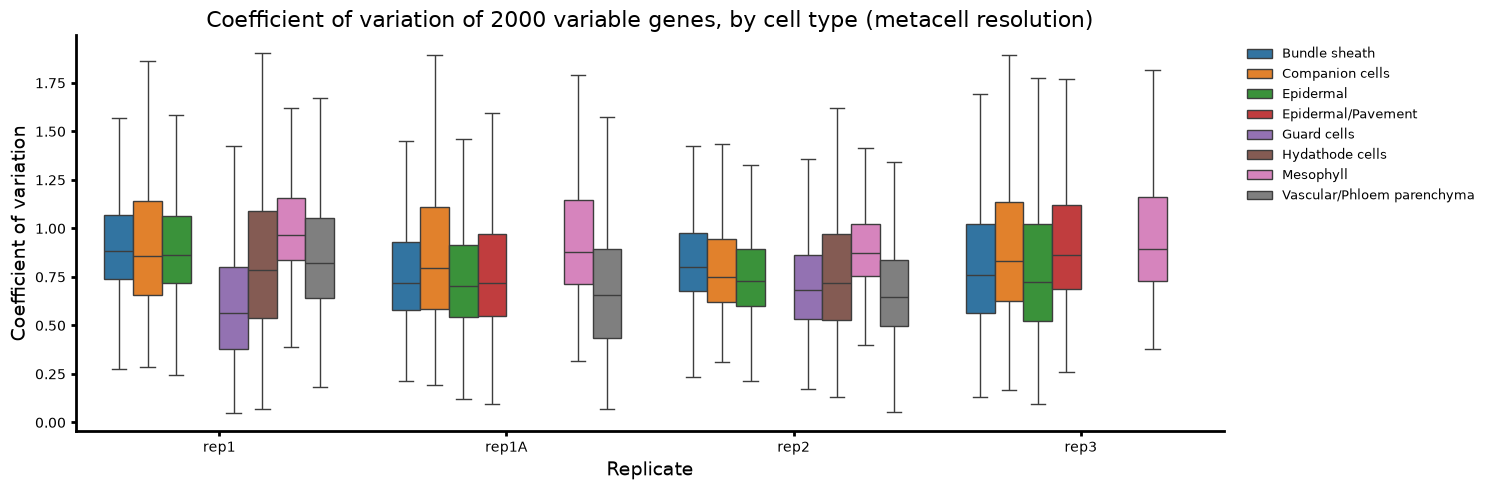

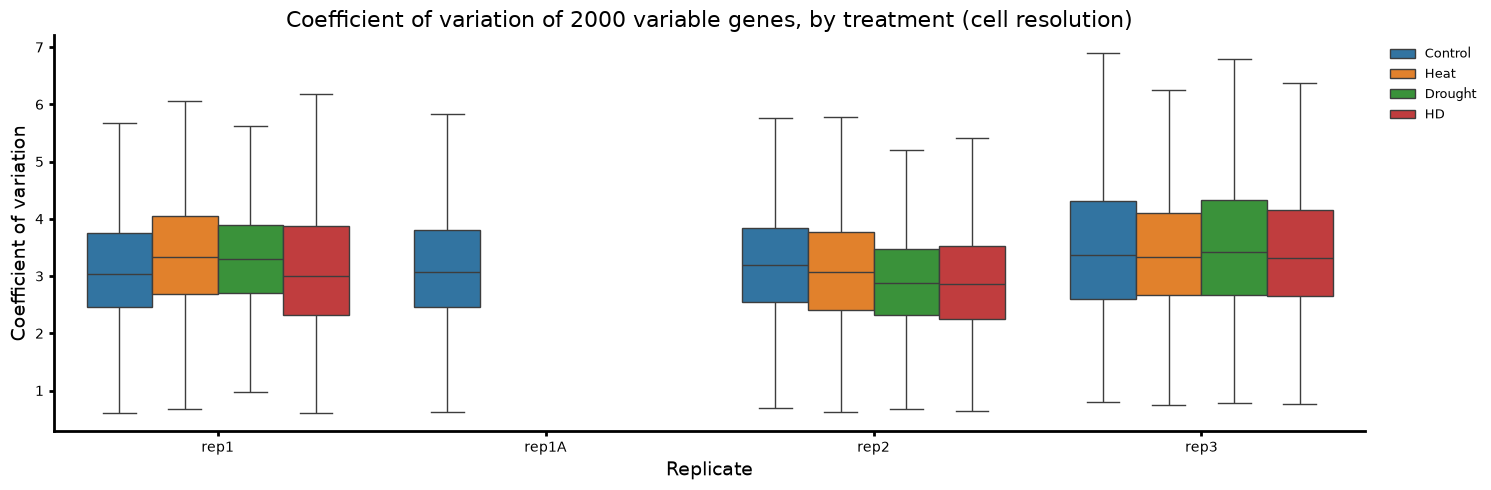

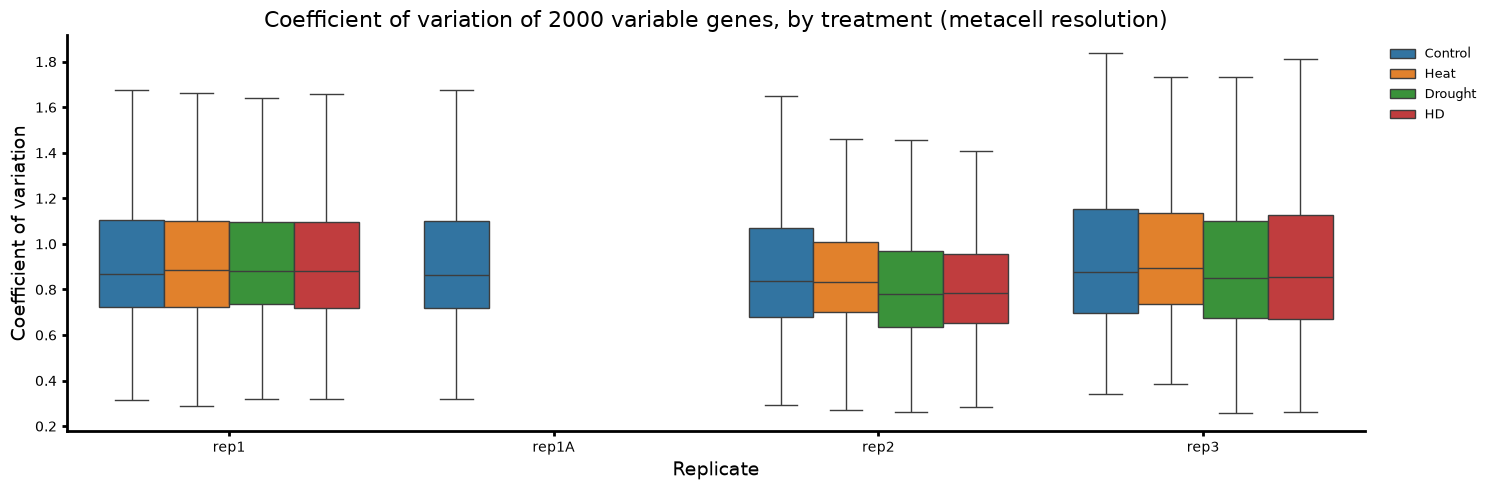

In [ ]:
for metric, ylabel in METRIC_LABELS.items():
    for split in SPLITS:
        for resolution in ("cell", "metacell"):
            d = variation[
                (variation["split_by"] == split)
                & (variation["resolution"] == resolution)
            ]
            styled_boxplot(
                d,
                x="replicate",
                y=metric,
                hue="group",
                xlabel="Replicate",
                ylabel=ylabel,
                hue_order=(
                    TREATMENT_ORDER
                    if split == "treatment"
                    else sorted(d["group"].unique())
                ),
                title=f"{ylabel} of {N_HVG} variable genes, by {SPLIT_LABELS[split]} "
                f"({resolution} resolution)",
            )

In [20]:
variation.to_csv(OUTDIR / "within_replicate_variation.csv", index=False)

summary = (
    variation.groupby(["resolution", "split_by", "replicate", "group"], observed=True)[
        ["median", "cv", "mad_over_median", "fano", "detection", "n_units"]
    ]
    .median()
    .round(4)
)
summary.to_csv(OUTDIR / "within_replicate_variation_summary.csv")
print(f"wrote both to {OUTDIR.resolve()}")
summary.head(12)

wrote both to C:\Users\mikep\git\Soybean_Single_Cell_drought_heat\Initial_exploration\qc_results


median      cv  mad_over_median     fano  detection  n_units
resolution split_by      replicate group                                                                                   
cell       celltype_call rep1      Bundle sheath                  0.0  3.1517              1.0  14.2426     0.1131   1897.0
                                   Companion cells                0.0  3.1163              1.0  10.9479     0.1258    787.0
                                   Epidermal                      0.0  3.0666              1.0  13.0054     0.1272   1317.0
                                   Epidermal/Pavement             0.0  3.4627              1.0  13.3647     0.0800     25.0
                                   Guard cells                    0.0  2.8768              1.0  11.5442     0.1479    169.0
                                   Hydathode cells                0.0  3.0787              1.0  10.6975     0.1226    155.0
                                   Mesophyll                      0.0  3.0160              1.0  13.2287     0.1325   6925.0
                                   Unknown                        0.0  3.1948              1.0  10.1751     0.1111     99.0
                                   Vascular/Phloem parenchyma     0.0  3.1593              1.0  13.1508     0.1155    277.0
                         rep1A     Bundle sheath                  0.0  3.0780              1.0  12.9037     0.1109    676.0
                                   Companion cells                0.0  3.1820              1.0  10.7893     0.1079    241.0
                                   Epidermal                      0.0  3.0399              1.0  12.5853     0.1133    309.0

### Reading the plots

* At **cell** resolution the median panel is a flat line at zero, and that is the finding, not
  a bug: 98% of gene x group medians are zero. Only the metacell panel carries level
  information.
* CV falls from ~3.1 (cell) to ~0.8 (metacell). Most cell-level CV is sampling noise, not
  biology - metacell Fano sits near 1, which is what pure Poisson sampling looks like.
* Differences between cell types and between treatments *within* a replicate are small
  compared with the differences between replicates. This is the same batch dominance seen in
  the organelle table above and in `Claude_analysis/README.md`.

### Other variation metrics that could be added

Already computed and in `variation`, just not plotted - say the word and they get panels:

1. **`fano`** (variance / mean) - separates sampling noise from real over-dispersion, since
   Fano ~ 1 is what Poisson alone produces. Probably the most informative single addition.
2. **`mad_over_median`** - robust CV. Usable at metacell resolution (8% undefined), useless at
   cell resolution (98% undefined).
3. **`detection`** - fraction of units expressing the gene. At this depth it drives CV, so it
   is worth plotting alongside to show what CV is actually tracking.

Not yet computed, each a small addition:

4. **Between- vs within-group variance ratio** (eta^2 or ICC) per gene: of a gene's variance
   inside one replicate, how much is explained by cell type versus residual? This answers
   "is the within-replicate variation structured, or noise?" directly, which the CV
   distributions only imply.
5. **Distance to group centroid** per cell/metacell in PCA space - transcriptome-level
   heterogeneity rather than per-gene, so one number per unit and much easier to read.
6. **Max fold-change across groups** within a replicate - blunt, but it names the genes
   driving the spread instead of only describing the distribution.
7. **Metacell-size sensitivity** - rerun at `TARGET_METACELL_SIZE` 10 / 20 / 50 to show how
   much of the cell-to-metacell change is aggregation artefact rather than signal.